## MONTE CARLO SENSITIVITY ANALYSIS
___
Cluster labels: 
* 0 – Core Frontline Operations Staff (E&I)
* 1 – Specialized Technical Field Experts (E&I)
* 2 – Advanced Governance & Support Specialists
* 3 – Essential Infrastructure Field Crew (E&I)
* 4 – Strategic Business & Real Estate Leaders
* 5 – Governance & Support Professionals

Python downstream analysis:
1. Time-to-Crisis distributions: Histograms per scenario showing spread of warning and crisis years across 500 runs.
2. FRI confidence bands: 90% CI ribbons around E&I, B&M, T&D, SS&G trajectories per scenario.
3. Tornado chart: Parameter sensitivity ranked by contribution to Time-to-Crisis variance.
4. Tier 1 minimum score distributions: The distribution of minimum average E&I score recorded over the full 34-year horizon across all 500 runs per scenario.
5. Parameter sensitivity on CRISIS year: Spearman rank correlation between each parameter and crisisYear.
6. Warning-To-Crisis window distribution: Distribution of the policy intervention window (crisisYear − warningYear).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr

In [ ]:
# DATASET PREPARATION
# Sensitivity Analysis · Scenarios A, B, F: 500 runs × 34 years × 3 scenarios = 51,000 rows
# Parameters varied: bScale, scoreOffset, quotaTimingOffset, quotaSizeScale, quotaFreqYears
patha = 'MC_SCENARIO0.csv'
pathb = 'MC_SCENARIO1.csv'
pathf = 'MC_SCENARIO5.csv'
mca = pd.read_csv(patha)
mcb = pd.read_csv(pathb)
mcf = pd.read_csv(pathf)

mca['scenarioID'] = 0
mcb['scenarioID'] = 1
mcf['scenarioID'] = 5
mc = pd.concat([mca, mcb, mcf], ignore_index=True)


mc['warning'] = mc['warning'].replace(-1.0, np.nan)
mc['crisis']  = mc['crisis'].replace(-1.0, np.nan)
mc['warningYear'] = mc['warning'].dropna().apply(lambda x: int(round(x))).reindex(mc.index)
mc['crisisYear']  = mc['crisis'].dropna().apply(lambda x: int(round(x))).reindex(mc.index)
mc['simYearInt']  = mc['simYear'].apply(lambda x: int(round(x)))

# SCENARIO LABELS
SLABELS = {
    0: 'Scenario A · Intended Baseline',
    1: 'Scenario B · Periodic Quota Continuation',
    5: 'Scenario F · Complete No-Quota',
}
SCOLOURS = {
    0: '#2980B9',
    1: '#27AE60',
    5: '#C0392B',
}
print(f'# TOTAL ROWS        : {len(mc):,}')
print(f'SCENARIO TYPE       : {sorted(mc['scenarioID'].unique())}')
print(f'# RUNS PER SCENARIO : {mc.groupby('scenarioID')['run'].nunique().to_dict()}')
print(f'YEARS PER RUN       : {mc.groupby('scenarioID')['simYearInt'].nunique().to_dict()}')
print(f'WARNING NaN COUNT   : {mc['warningYear'].isna().sum():,} (runs where WARNING never triggered)')
print(f'CRISIS NaN COUNT    : {mc['crisisYear'].isna().sum():,} (runs where CRISIS never triggered)')

# TOTAL ROWS        : 51,000
SCENARIO TYPE       : [np.int64(0), np.int64(1), np.int64(5)]
# RUNS PER SCENARIO : {0: 500, 1: 500, 5: 500}
YEARS PER RUN       : {0: 34, 1: 34, 5: 34}
WARNING NaN COUNT   : 29,584 (runs where WARNING never triggered)
CRISIS NaN COUNT    : 41,108 (runs where CRISIS never triggered)


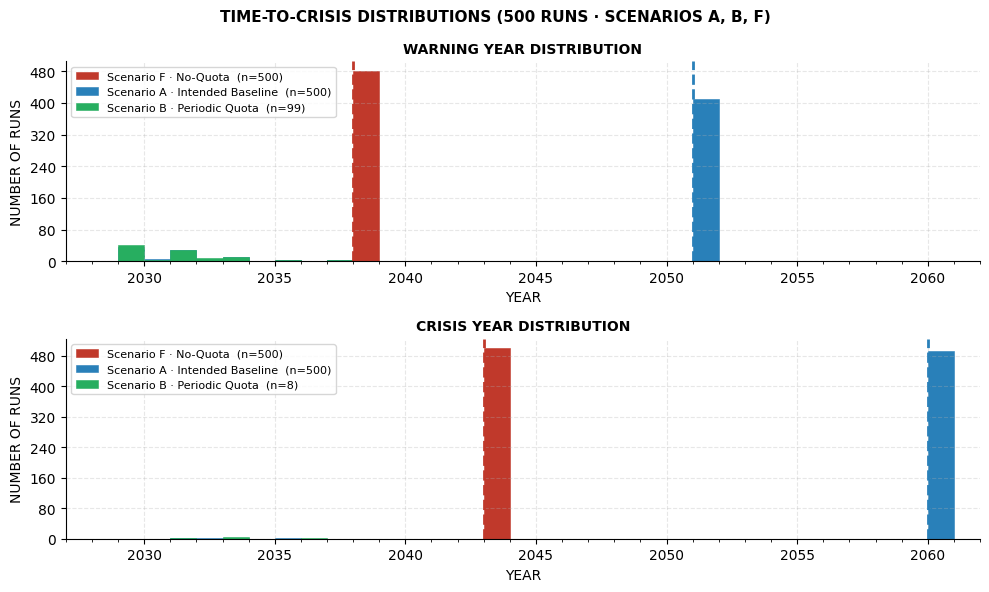

In [ ]:
# MC PLOT 1 — TIME-TO-CRISIS DISTRIBUTIONS
rsummary = (
    mc.groupby(['scenarioID', 'run'])
    .agg(
        warningYear=('warningYear', 'max'),
        crisisYear=('crisisYear', 'max'),
        bScale=('bScale', 'first'),
        scoreOffset=('scoreOffset', 'first'),
        quotaTimingOffset=('quotaTimingOffset', 'first'),
        quotaSizeScale=('quotaSizeScale', 'first'),
        quotaFreqYears=('quotaFreqYears', 'first'),
    )
    .reset_index()
)
rsummary['window'] = rsummary['crisisYear'] - rsummary['warningYear']
SORDER = [5, 0, 1]   # WORST → BEST
SSHORT  = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota',
    5: 'F · No-Quota',
}
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for ax, col, title in zip(
    axes,
    ['warningYear', 'crisisYear'],
    ['WARNING YEAR DISTRIBUTION', 'CRISIS YEAR DISTRIBUTION'],
):
    for sid in SORDER:
        subset = rsummary[rsummary['scenarioID'] == sid][col].dropna()
        if len(subset) == 0:
            continue
        colour = SCOLOURS[sid]
        ax.hist(
            subset,
            bins=range(2027, 2062, 1),
            color=colour,
            edgecolor=colour,
            linewidth=0.4,
            label=f'Scenario {SSHORT[sid]}  (n={len(subset)})',
        )
    det = {'warningYear': {0: 2051, 5: 2038}, 'crisisYear': {0: 2060, 5: 2043}}
    for sid, yr in det[col].items():
        ax.axvline(yr, color=SCOLOURS[sid], linestyle='--', linewidth=2.0)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('YEAR')
    ax.set_ylabel('NUMBER OF RUNS')
    ax.set_xlim(2027, 2062)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)
    sns.despine()
fig.suptitle('TIME-TO-CRISIS DISTRIBUTIONS (500 RUNS · SCENARIOS A, B, F)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('F8.png', dpi=600, bbox_inches='tight')
plt.show();

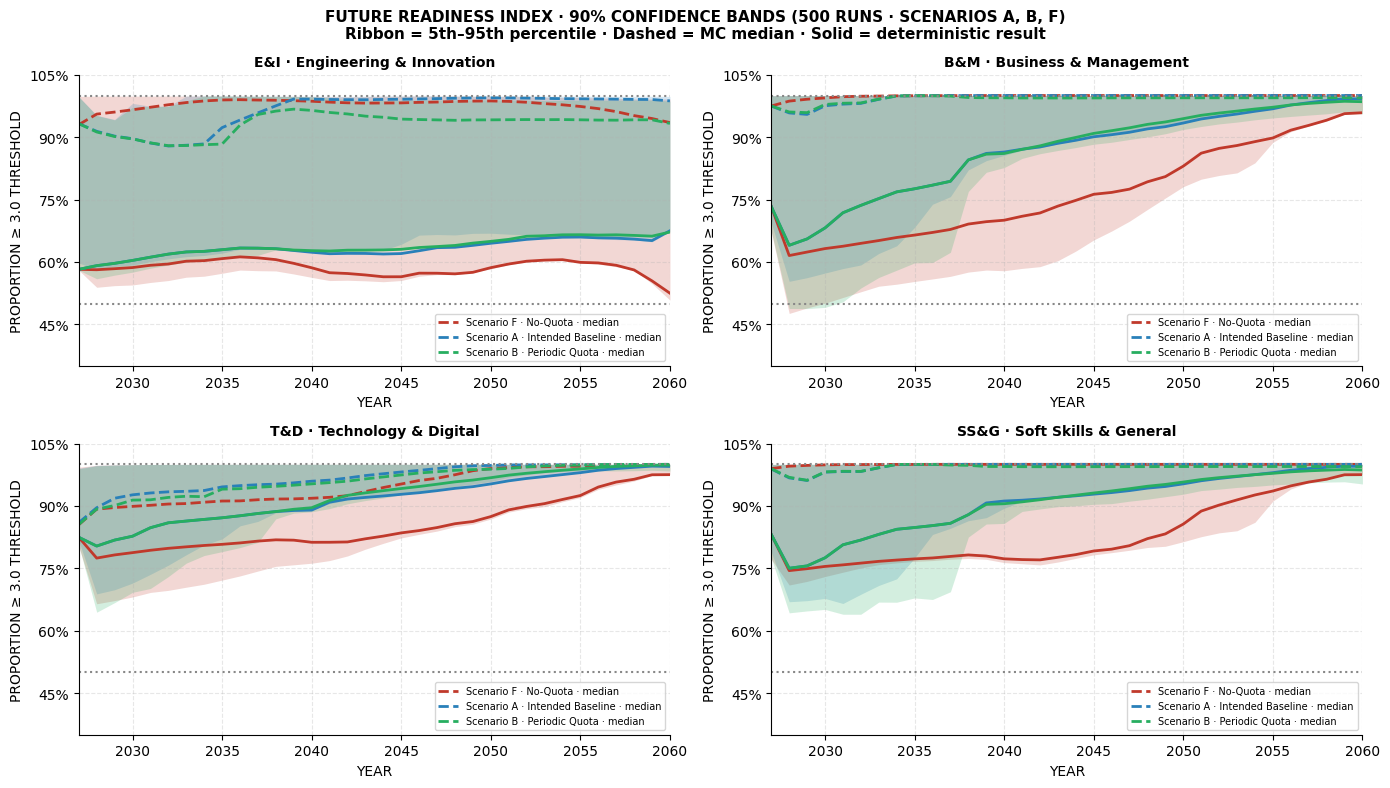

In [ ]:
# MC PLOT 2 — FRI CONFIDENCE BANDS · 90% CI · SCENARIOS A, B, F
# For each skill dimension: median + 5th–95th percentile ribbon per scenario. Deterministic result overlaid as solid line
FRIC = {
    'friEI':  'E&I · Engineering & Innovation',
    'friBM':  'B&M · Business & Management',
    'friTD':  'T&D · Technology & Digital',
    'friSSG': 'SS&G · Soft Skills & General',
}
det = pd.read_csv('SCENARIOAF.csv')
dlabels = {0: 'A', 1: 'B', 5: 'F'}
def cbands(df, col):
    return (
        df.groupby(['scenarioID', 'simYearInt'])[col]
        .agg(
            median=lambda x: x.quantile(0.50),
            lo=lambda x: x.quantile(0.05),
            hi=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )

SORDER = [5, 0, 1]
SSHORT = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota',
    5: 'F · No-Quota',
}
SCOLOURS = {
    0: '#2980B9',
    1: '#27AE60',
    5: '#C0392B',
}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, (col, dim) in zip(axes, FRIC.items()):
    bands = cbands(mc, col)
    for sid in SORDER:
        colour = SCOLOURS[sid]
        b = bands[bands['scenarioID'] == sid]
        ax.fill_between(b['simYearInt'], b['lo'], b['hi'], color=colour, alpha=0.2, linewidth=0)
        ax.plot(b['simYearInt'], b['median'], color=colour, linewidth=2.0, linestyle='--',label=f'Scenario {SSHORT[sid]} · median')
        det_s = det[det['scenarioID'] == sid]
        if len(det_s) > 0:
            ax.plot(det_s['year'], det_s[col], color=colour, linewidth=2.0, linestyle='-')

    ax.axhline(1.0, color='#888888', linestyle=':')
    ax.axhline(0.5, color='#888888', linestyle=':')
    ax.set_title(dim, fontsize=10, fontweight='bold')
    ax.set_xlabel('YEAR')
    ax.set_ylabel('PROPORTION ≥ 3.0 THRESHOLD')
    ax.set_xlim(2027, 2060)
    ax.set_ylim(0.35, 1.05)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.3)
    sns.despine()

fig.suptitle(
    'FUTURE READINESS INDEX · 90% CONFIDENCE BANDS (500 RUNS · SCENARIOS A, B, F)\n'
    'Ribbon = 5th–95th percentile · Dashed = MC median · Solid = deterministic result',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('F9.png', dpi=600, bbox_inches='tight')
plt.show();

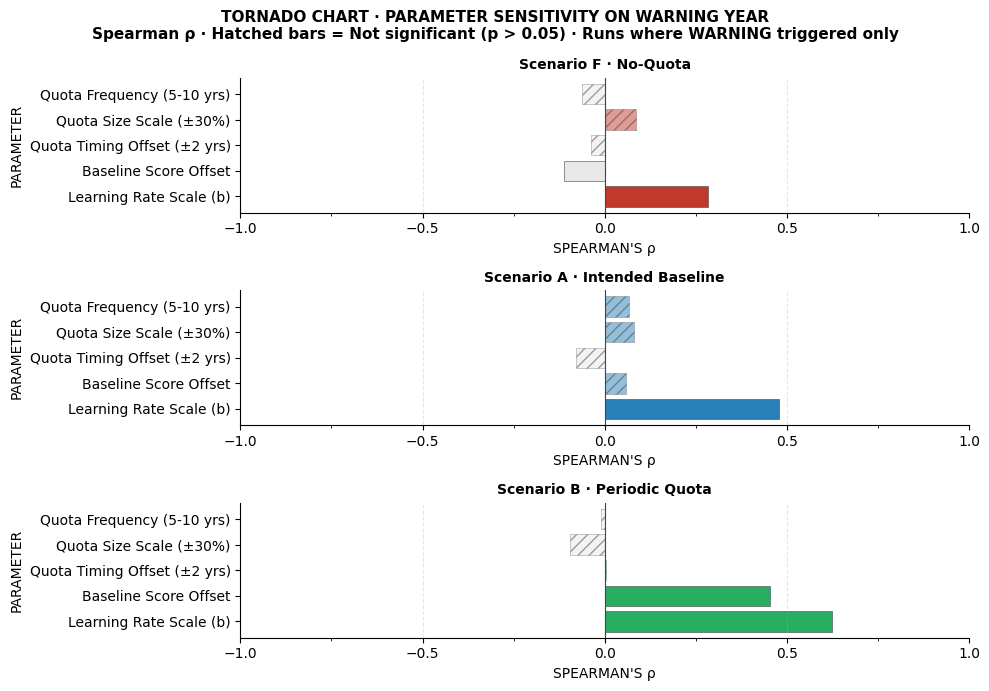

In [ ]:
# MC PLOT 3 — TORNADO CHART · PARAMETER SENSITIVITY ON WARNING YEAR
# Metric: Spearman rank correlation between each parameter and warningYear. Computed per scenario and it only runs where WARNING was triggered included
PARAMS = {
    'bScale':            'Learning Rate Scale (b)',
    'scoreOffset':       'Baseline Score Offset',
    'quotaTimingOffset': 'Quota Timing Offset (±2 yrs)',
    'quotaSizeScale':    'Quota Size Scale (±30%)',
    'quotaFreqYears':    'Quota Frequency (5-10 yrs)',
}
SORDER  = [5, 0, 1]
SSHORT  = {
    0: 'Scenario A · Intended Baseline',
    1: 'Scenario B · Periodic Quota',
    5: 'Scenario F · No-Quota',
}
SCOLOURS = {
    0: '#2980B9',
    1: '#27AE60',
    5: '#C0392B',
}
records = []
for sid in SORDER:
    subset = rsummary[(rsummary['scenarioID'] == sid) & rsummary['warningYear'].notna()]
    if len(subset) < 10:
        continue
    for param in PARAMS:
        rho, pval = spearmanr(subset[param], subset['warningYear'])
        records.append({
            'scenarioID': sid,
            'param': param,
            'rho': rho,
            'pval': pval,
        })
corr = pd.DataFrame(records)
scrisis = sorted(corr['scenarioID'].unique())

fig, axes = plt.subplots(len(SORDER), 1, figsize=(10, 2.0 * len(scrisis) + 1), sharey=True)
for ax, sid in zip(axes, SORDER):
    subset = corr[corr['scenarioID'] == sid].copy()
    subset = subset.set_index('param').reindex(list(PARAMS.keys()))
    colour = SCOLOURS[sid]
    bars = ax.barh(
        [PARAMS[p] for p in PARAMS],
        subset['rho'],
        color=[colour if r >= 0 else '#E8E8E8' for r in subset['rho']],
        edgecolor='#444444',
        linewidth=0.4,
        height=0.8
    )
    for bar, (_, row) in zip(bars, subset.iterrows()):
        if row['pval'] > 0.05:
            bar.set_hatch('///')
            bar.set_alpha(0.5)
    ax.axvline(0, color='#444444', linewidth=0.8)
    ax.set_xlim(-1.0, 1.0)
    ax.set_title(SSHORT[sid], fontsize=10, fontweight='bold')
    ax.set_xlabel("SPEARMAN'S ρ")
    ax.set_ylabel('PARAMETER')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.25))
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)
    sns.despine()

fig.suptitle(
    'TORNADO CHART · PARAMETER SENSITIVITY ON WARNING YEAR\n'
    'Spearman ρ · Hatched bars = Not significant (p > 0.05) · Runs where WARNING triggered only',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('F10.png', dpi=600, bbox_inches='tight')
plt.show();

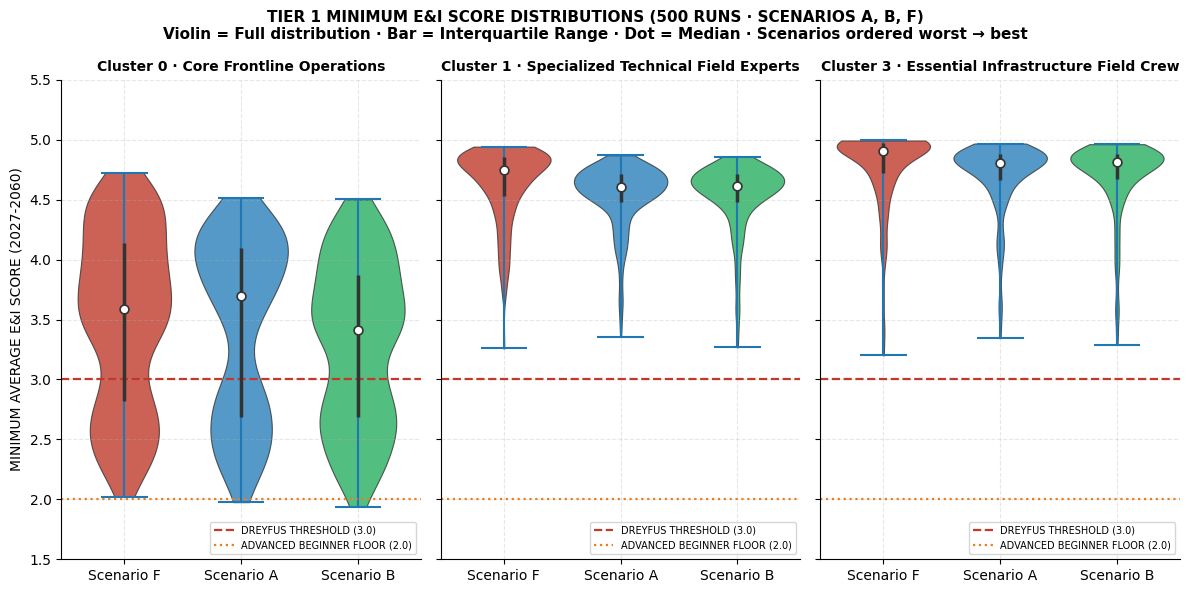

In [ ]:
# MC PLOT 4 — TIER 1 MINIMUM E&I SCORE DISTRIBUTIONS
# For each Tier 1 cluster (0, 1, 3): distribution of minimum average E&I score recorded over the full 34-year horizon across all 500 runs per scenario. Violin plots with embedded median marker are used.
# Reference lines: 3.0 (Dreyfus safety threshold) · 2.0 (Advanced Beginner floor)
TIER1 = {
    'minEI0': 'Cluster 0 · Core Frontline Operations',
    'minEI1': 'Cluster 1 · Specialized Technical Field Experts',
    'minEI3': 'Cluster 3 · Essential Infrastructure Field Crew',
}
SORDER  = [5, 0, 1]
SSHORT  = {
    0: 'A',
    1: 'B',
    5: 'F',
}
SCOLOURS = {
    0: '#2980B9',
    1: '#27AE60',
    5: '#C0392B',
}
rmin = (
    mc.groupby(['scenarioID', 'run'])
    .agg(
        minEI0=('minEI0', 'min'),
        minEI1=('minEI1', 'min'),
        minEI3=('minEI3', 'min'),
    )
    .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
for ax, (col, clabel) in zip(axes, TIER1.items()):
    plotdata  = []
    positions  = []
    ticklabels = []
    for i, sid in enumerate(SORDER):
        vals = rmin[rmin['scenarioID'] == sid][col].dropna().values
        plotdata.append(vals)
        positions.append(i + 1)
        ticklabels.append(f'Scenario {SSHORT[sid]}')

    parts = ax.violinplot(
        plotdata,
        positions=positions,
        showmedians=False,
        showextrema=True,
        widths=0.8,
    )

    for pc, sid in zip(parts['bodies'], SORDER):
        pc.set_facecolor(SCOLOURS[sid])
        pc.set_edgecolor('#333333')
        pc.set_linewidth(0.8)
        pc.set_alpha(0.8)

    for i, (sid, pos) in enumerate(zip(SORDER, positions)):
        vals = rmin[rmin['scenarioID'] == sid][col].dropna().values
        med = np.median(vals)
        q1, q3 = np.percentile(vals, [25, 75])
        ax.vlines(pos, q1, q3, color='#333333', linewidth=2.5, zorder=3)
        ax.scatter(pos, med, color='white', edgecolor='#333333', s=40, zorder=4, linewidth=1.2)

    ax.axhline(3.0, color='#C0392B', linewidth=1.6, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
    ax.axhline(2.0, color='#E67E22', linewidth=1.6, linestyle=':', label='ADVANCED BEGINNER FLOOR (2.0)')
    ax.set_title(clabel, fontsize=10, fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(ticklabels)
    ax.set_ylim(1.5, 5.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')
    sns.despine()
axes[0].set_ylabel('MINIMUM AVERAGE E&I SCORE (2027-2060)')

fig.suptitle(
    'TIER 1 MINIMUM E&I SCORE DISTRIBUTIONS (500 RUNS · SCENARIOS A, B, F)\n'
    'Violin = Full distribution · Bar = Interquartile Range · Dot = Median · Scenarios ordered worst → best',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('F11.png', dpi=600, bbox_inches='tight')
plt.show();

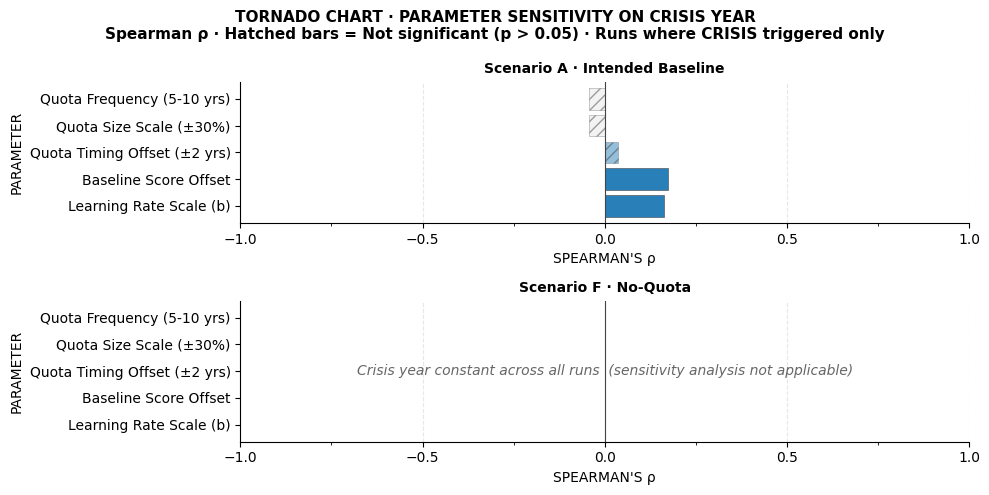

In [7]:
# MC PLOT 5 — TORNADO CHART · PARAMETER SENSITIVITY ON CRISIS YEAR
# Metric: Spearman rank correlation between each parameter and crisisYear. This was computed per scenario · only runs where CRISIS was triggered included.
import warnings
from scipy.stats import ConstantInputWarning
SSHORT  = {
    0: 'Scenario A · Intended Baseline',
    1: 'Scenario B · Periodic Quota',
    5: 'Scenario F · No-Quota',
}
cri = []
for sid in SORDER:
    subset = rsummary[(rsummary['scenarioID'] == sid) & rsummary['crisisYear'].notna()]
    if len(subset) < 10:
        continue
    for param in PARAMS:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', ConstantInputWarning)
            rho, pval = spearmanr(subset[param], subset['crisisYear'])
        cri.append({
            'scenarioID': sid,
            'param': param,
            'rho': float('nan') if str(rho) == 'nan' else rho,
            'pval': pval,
            'constant': subset['crisisYear'].nunique() == 1,
        })

corr_c = pd.DataFrame(cri)
scrisis = sorted(corr_c['scenarioID'].unique())
fig, axes = plt.subplots(len(scrisis), 1, figsize=(10, 2.0 * len(scrisis) + 1), sharey=True)
if len(scrisis) == 1:
    axes = [axes]

for ax, sid in zip(axes, scrisis):
    subset = corr_c[corr_c['scenarioID'] == sid].copy()
    subset = subset.set_index('param').reindex(list(PARAMS.keys()))
    colour = SCOLOURS[sid]
    nruns = rsummary[(rsummary['scenarioID'] == sid) & rsummary['crisisYear'].notna()]
    isconstant = subset['constant'].any()
    bars = ax.barh(
        [PARAMS[p] for p in PARAMS],
        subset['rho'].fillna(0),
        color=[colour if (r >= 0 and not pd.isna(r)) else '#E8E8E8'
               for r in subset['rho']],
        edgecolor='#444444',
        linewidth=0.4,
        height=0.8,
    )
    for bar, (_, row) in zip(bars, subset.iterrows()):
        if pd.isna(row['rho']) or row['pval'] > 0.05:
            bar.set_hatch('///')
            bar.set_alpha(0.5)

    if isconstant:
        ax.text(0.5, 0.5,
                'Crisis year constant across all runs  (sensitivity analysis not applicable)', transform=ax.transAxes, ha='center', va='center', fontsize=10, color='#666666', style='italic')

    ax.axvline(0, color='#444444', linewidth=0.8)
    ax.set_xlim(-1.0, 1.0)
    ax.set_title(f'{SSHORT[sid]}', fontsize=10, fontweight='bold')
    ax.set_xlabel("SPEARMAN'S ρ")
    ax.set_ylabel('PARAMETER')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.25))
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)
    sns.despine()

fig.suptitle(
    'TORNADO CHART · PARAMETER SENSITIVITY ON CRISIS YEAR\n'
    'Spearman ρ · Hatched bars = Not significant (p > 0.05) · Runs where CRISIS triggered only',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('F12.png', dpi=600, bbox_inches='tight')
plt.show();

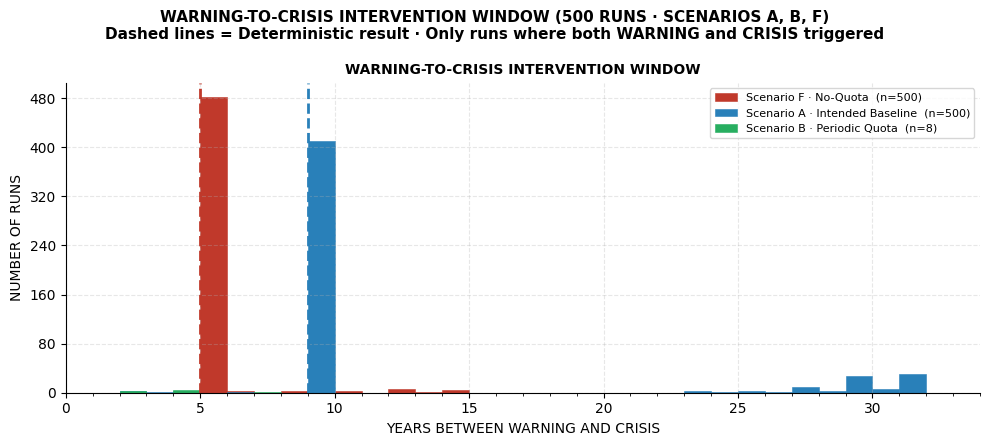

In [ ]:
# MC PLOT 6 — WARNING-TO-CRISIS WINDOW DISTRIBUTION
# For runs where both WARNING and CRISIS are triggered: Distribution of the policy intervention window (crisisYear − warningYear).
SORDER  = [5, 0, 1]
SSHORT  = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota',
    5: 'F · No-Quota',
}
SCOLOURS = {
    0: '#2980B9',
    1: '#27AE60',
    5: '#C0392B',
}
rsummary['window'] = rsummary['crisisYear'] - rsummary['warningYear']
win = rsummary[rsummary['window'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))
for sid in SORDER:
    subset = win[win['scenarioID'] == sid]['window'].dropna()
    if len(subset) == 0:
        continue
    colour = SCOLOURS[sid]
    ax.hist(
        subset,
        bins=range(0, 35, 1),
        color=colour,
        edgecolor=colour,
        linewidth=0.4,
        label=f'Scenario {SSHORT[sid]}  (n={len(subset)})',
    )

detwin = {0: 2060 - 2051, 5: 2043 - 2038}
for sid, w in detwin.items():
    ax.axvline(w, color=SCOLOURS[sid], linewidth=2.0, linestyle='--')

ax.set_title('WARNING-TO-CRISIS INTERVENTION WINDOW', fontsize=10, fontweight='bold')
ax.set_xlabel('YEARS BETWEEN WARNING AND CRISIS')
ax.set_ylabel('NUMBER OF RUNS')
ax.set_xlim(0, 34)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
fig.suptitle(
    'WARNING-TO-CRISIS INTERVENTION WINDOW (500 RUNS · SCENARIOS A, B, F)\n'
    'Dashed lines = Deterministic result · Only runs where both WARNING and CRISIS triggered',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('F13.png', dpi=600, bbox_inches='tight')
plt.show();

___
**END**